In [1]:
from minisom import MiniSom
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import datasets
from sklearn.preprocessing import scale
from scipy.interpolate import griddata
from sklearn.preprocessing import LabelBinarizer
import numpy as np
import pandas as pd
import math

In [2]:
file_path = "WVS_Cross-National_Wave_7_csv_v6_0.csv"

wvs = pd.read_csv(file_path)#, low_memory=False)

wvs.columns = wvs.columns.str.upper()

/var/folders/sl/vnf426s55n5b1nyg0gf3qr4r0000gn/T/ipykernel_84925/3349751548.py:3: DtypeWarning: Columns (346,348,350,580,581,582,583) have mixed types. Specify dtype option on import or set low_memory=False.
  wvs = pd.read_csv(file_path)#, low_memory=False)


In [3]:
bad_col = []
for c in wvs.columns:
    for i in range(len(wvs[c])):
        if "str" in str(type(wvs[c][i])):
            #print(c + str(type(wvs[c][i])))
            bad_col.append(c)
            break

In [4]:
clean_wvs = wvs
for c in bad_col:
    clean_wvs = clean_wvs.drop(c, axis=1)

In [5]:
for c in clean_wvs.columns:
    if "str" in str(type(wvs[c][0])):
        print(c + str(type(wvs[c][0])))
        

In [6]:
counts = clean_wvs['B_COUNTRY'].value_counts()
print(counts)

124    4018
360    3200
156    3036
826    2609
840    2596
       ... 
32     1003
858    1000
196    1000
152    1000
909     447
Name: B_COUNTRY, Length: 66, dtype: int64


In [6]:
can_wvs = clean_wvs[clean_wvs['B_COUNTRY'] == 124].copy()

In [7]:
can_wvs = can_wvs.fillna(-1)
child_rearing_questions = [f"Q{i}" for i in range(7, 18)]
moral_questions = [f"Q{i}" for i in range(176, 187)]
selected_questions = child_rearing_questions + moral_questions
existing_questions = [q for q in selected_questions if q in wvs.columns]

X = can_wvs[existing_questions].to_numpy()
#Y = wvs["Q262"]
Y = can_wvs["X003R"].to_numpy()

In [8]:
b = []
print(X.shape)
for i in range(X.shape[1]):
    temp = np.corrcoef(Y,X[:,i])[0][1]
    if not np.isnan(temp):
        b.append(np.corrcoef(Y,X[:,i])[0][1])
b = np.array(b)
print(b.max(),b.min(), b.mean())

(4018, 22)
0.08214055134484513 -0.3529610711468601 -0.08544107792665954


In [9]:
["261","262","X003R","X003R2"]
X.shape

(4018, 22)

In [ ]:
SOM_DIM = int(5*X.shape[0]**.54)
print(SOM_DIM)
som = MiniSom(SOM_DIM, SOM_DIM, X.shape[1], sigma=.7,
              learning_rate=0.75, neighborhood_function='triangle')
som.pca_weights_init(X[:int(.1*len(X))])
#som.train(X, 500000, random_order=True, verbose=True)
som.train(X, 50, random_order=True, verbose=True)

441


/opt/homebrew/lib/python3.11/site-packages/minisom.py:235: UserWarning: sigma should be an integer >=1 when triangle or bubbleare used as neighborhood function
  warn('sigma should be an integer >=1 when triangle or bubble' +
/opt/homebrew/lib/python3.11/site-packages/minisom.py:447: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + \


 [ 50 / 50 ] 100% - 0:00:00 left 

In [12]:
def encode(X):
    vals = {}
    for i in range(len(X)):
        vals[X[i]] = 1
    lb = LabelBinarizer()
    lb.fit(list(vals.keys()))
    return (lb.classes_, vals.keys(), lb.transform(X))

'''
def generate_colors(max_val):
    colors = []
    for i in range(max_val):
        colors.append((np.random.rand(), np.random.rand(), np.random.rand()))
    return colors
'''
label_colors = {
    6: 'red',       
    1: 'blue',      
    2: 'green',     
    0: 'purple',    
    8: 'gray',      
    4: 'orange',    
    5: 'cyan',      
    9: 'magenta',   
    3: 'yellow',    
    7: 'brown',     
    10: 'lime',
    11: 'pink',
    12: 'teal',
    13: 'bisque',
    14: 'tan',
    15: 'black',
    16: 'white',
    17: 'powderblue',
    18: 'rosybrown',
    19: 'peru',
    20: 'deeppink',
    21: 'mediumpurple',
    22: 'plum',
    23: 'deepskyblue',
    24: 'darkseagreen',
    25: 'tomato',
    26: 'cadetblue',
    27: 'beige',
    28: 'navy',
    29: 'palevioletred',
    30: 'gainsboro'}

"""
    make_3d_graph makes a 3d surface map or a 3d point cloud out of the som with 4 sides shown
        * som = self organizing map trained on the dataset 
        * flie = (str) file the data comes from and will be used for the path the figures are saved to
        * X = (cp array) cell counts
        * Y = (np array) cell types
        * surface = (bool) whether or not to plot with the surface or not
"""
def make_3D_graph(som, X, Y, DIM, surface=False):
    classes_lb, labels, Y0 = encode(Y)
    #max_Y0 = Y0.max()
    #label_colors = generate_colors(len(classes_lb)) #max_Y0)
    #for side_view in range(4):
    if 1:
        side_view = 0
        fig = plt.figure(figsize=(50, 50))
        ax = fig.add_subplot(projection='3d')
        x = np.zeros(DIM * DIM).reshape((DIM,DIM))
        y = np.array(list(np.arange(DIM)) * DIM).reshape((DIM,DIM))


        for i in range(DIM):
            x[i,:] = i

        X = np.array(X)
        maps = som.distance_map()
        labels_map = som.labels_map(X, Y)
        if surface: 
            ax.plot_surface(x, y, som.distance_map(),cmap="viridis")

        AZIM = -side_view*90-45
        ax.view_init(elev=30, azim=AZIM, roll=0)

        mapped = 0

        points = np.zeros((Y.shape[0], 4))
        for x in range(DIM):
            for y in range(DIM):
                label_list = labels_map.get((x, y), [])
                if label_list:
                    for label in list(label_list.keys()):
                        index = np.where(classes_lb == label)[0][0]

                        points[mapped] = [x,y,maps[x][y],index]
                        mapped += 1

        for n,l in enumerate(classes_lb):
          mask = (points[:, 3] == n)
          plotters = np.copy(points[mask, :3])
          
          ax.scatter(plotters[:,0],plotters[:,1], plotters[:,2],color = label_colors[n], label=l)   
        ax.legend()

        colors_labels = []
        for n, l in enumerate(classes_lb):
          colors_labels.append([label_colors[n], str(l)])

        counts_lab = np.zeros(len(classes_lb))
        for y in Y0:
          if y.shape[0] <=1:
              index = y
          else:
              index = np.argmax(y)
          counts_lab[index] += 1

        tabled = np.array([np.array(classes_lb), counts_lab.astype(int)]).T
        ax.table(tabled)
        ax.set_xlabel('X coordinate of SOM')
        ax.set_ylabel('Y coordinate of SOM')
        ax.set_zlabel('Node Activation')

        plt.title('SOM with Labels Represented by Colors')
        plt.show("wvs_" + str(SOM_DIM) + ".png")
        return points

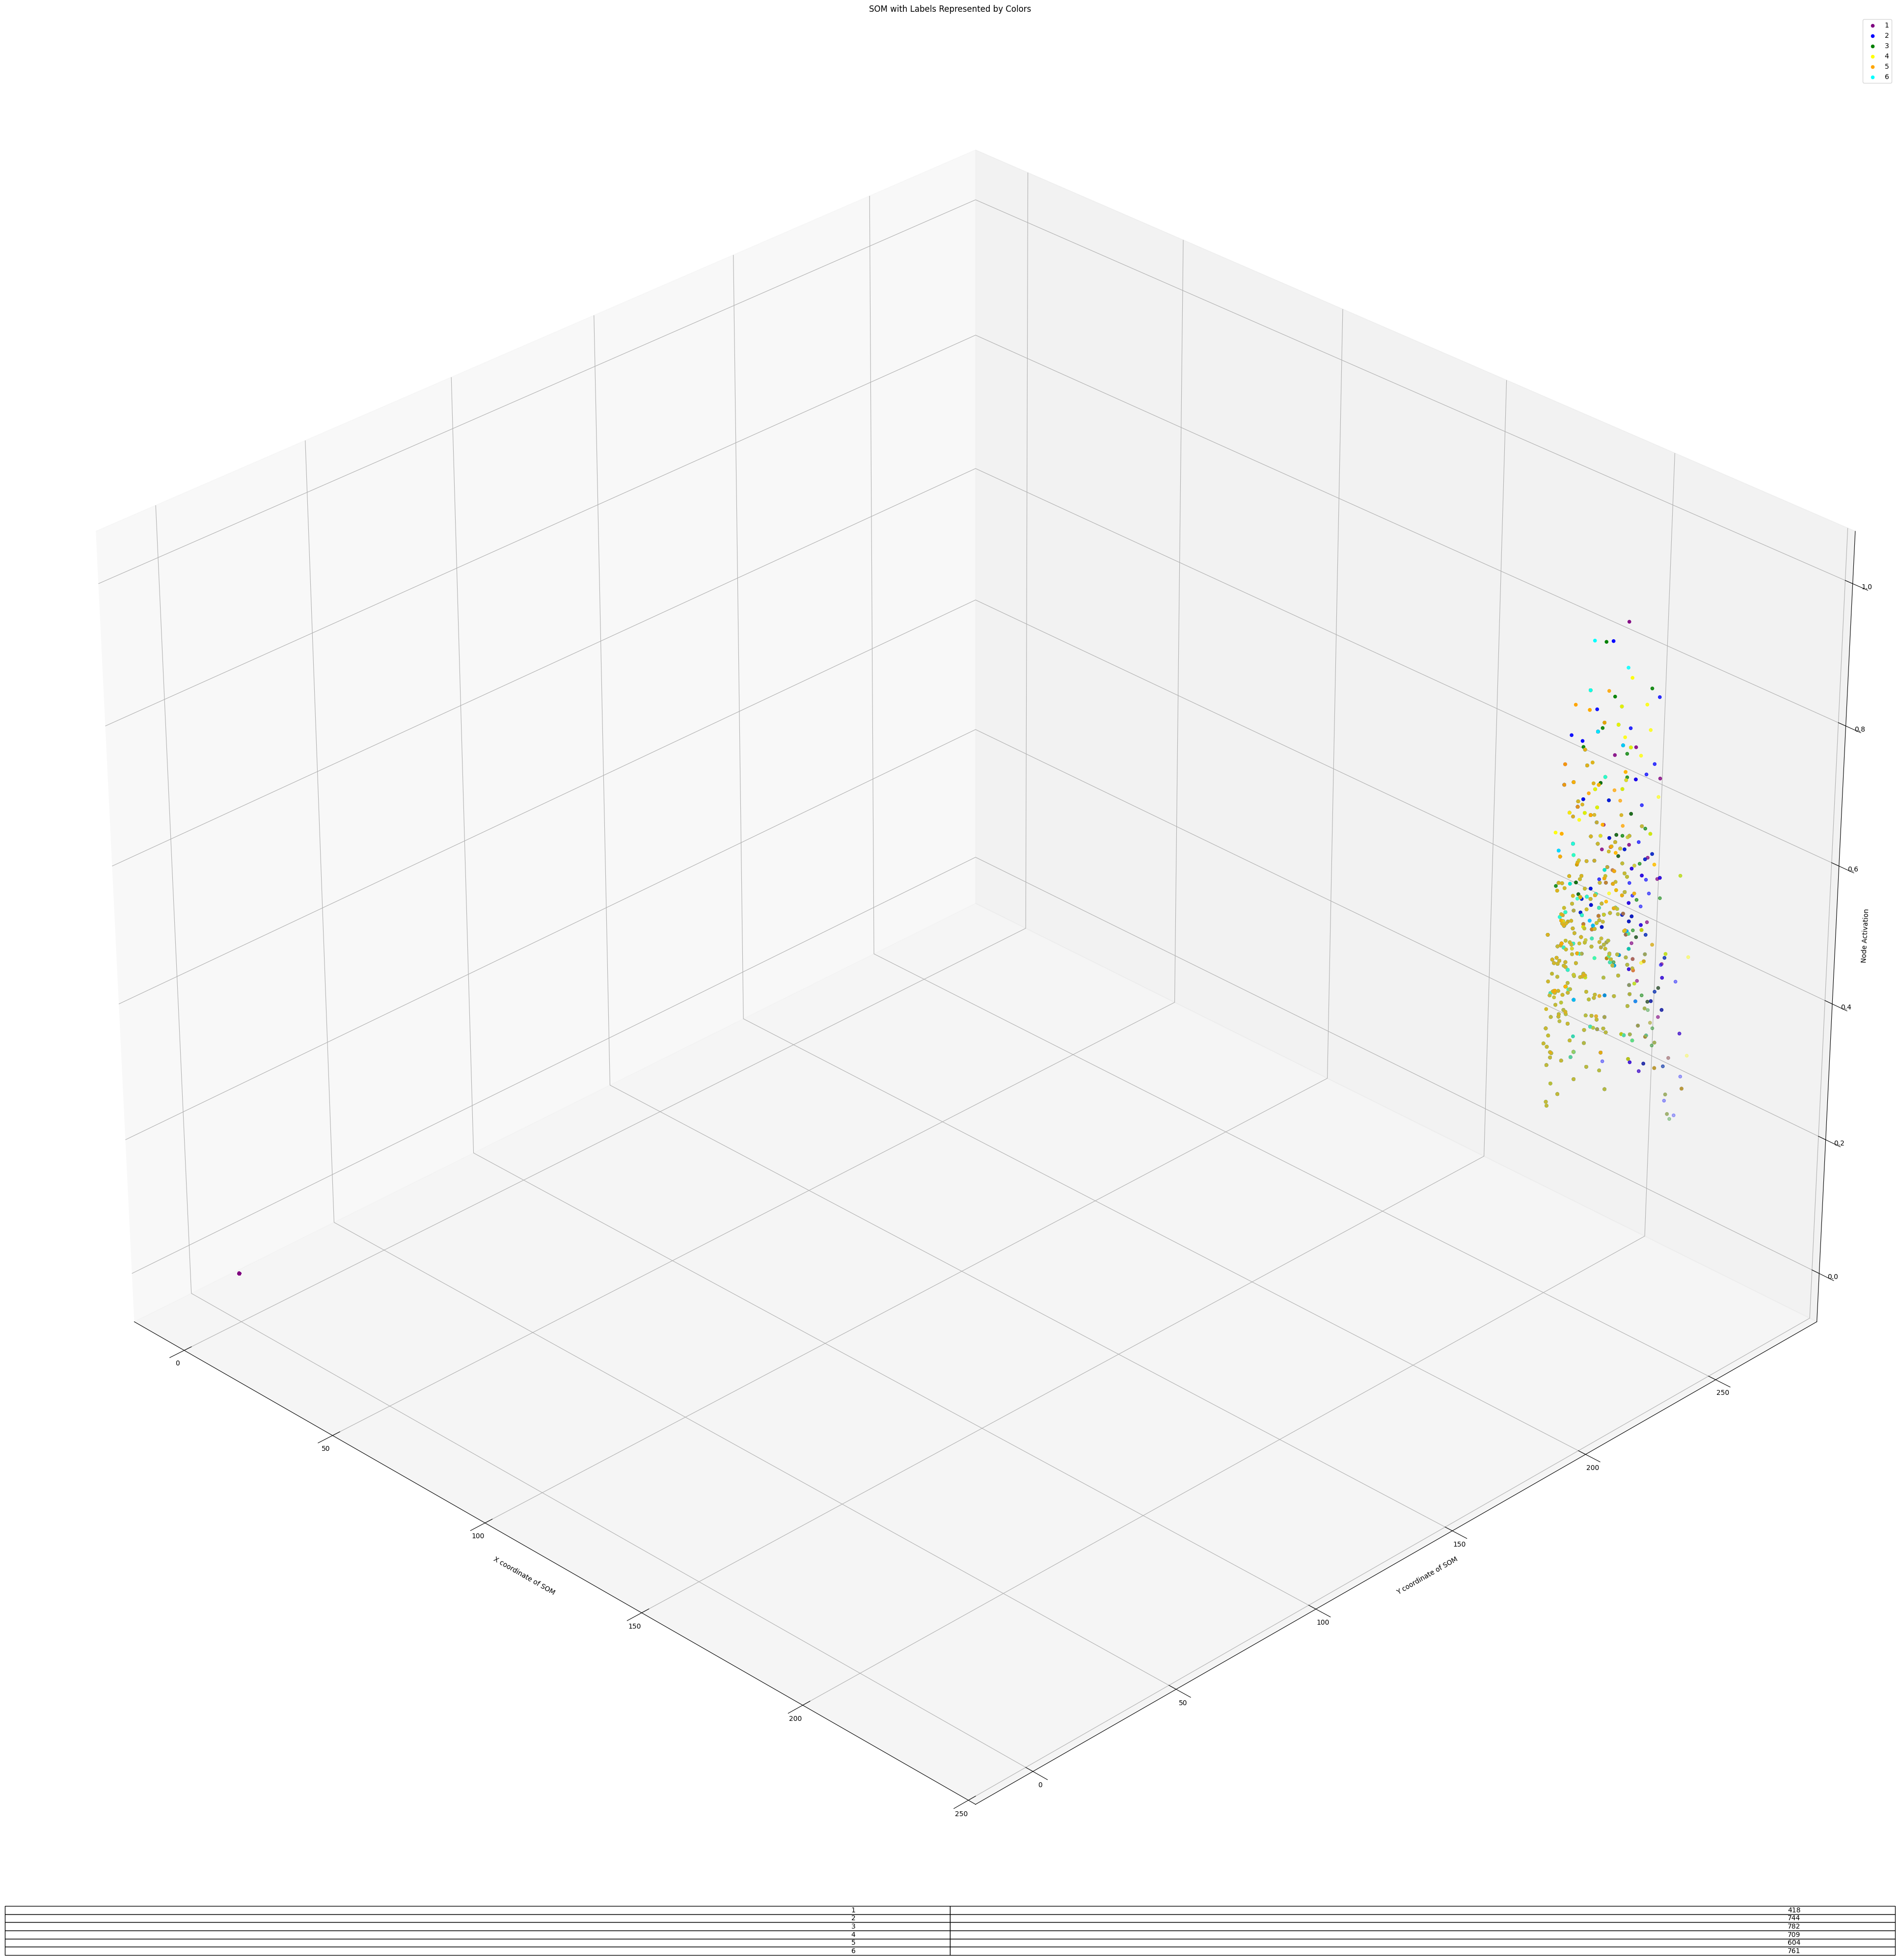

In [13]:
vals = make_3D_graph(som, X, Y, SOM_DIM)

purple 0.0
blue 1.0
green 2.0
yellow 3.0
orange 4.0
cyan 5.0


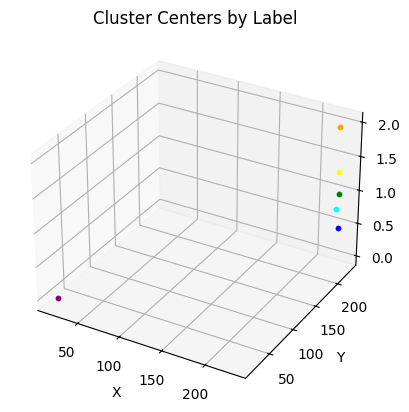

In [22]:
xyz = vals[:, :3]
labels = vals[:, 3]

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab)]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by Label")

plt.show()

In [36]:
np.corrcoef(labels, xyz[:,2])[0,1]

0.7501104266575759

In [38]:
import scipy

scipy.stats.spearmanr(labels, xyz[:,2])

SignificanceResult(statistic=0.8494060379546955, pvalue=0.0)

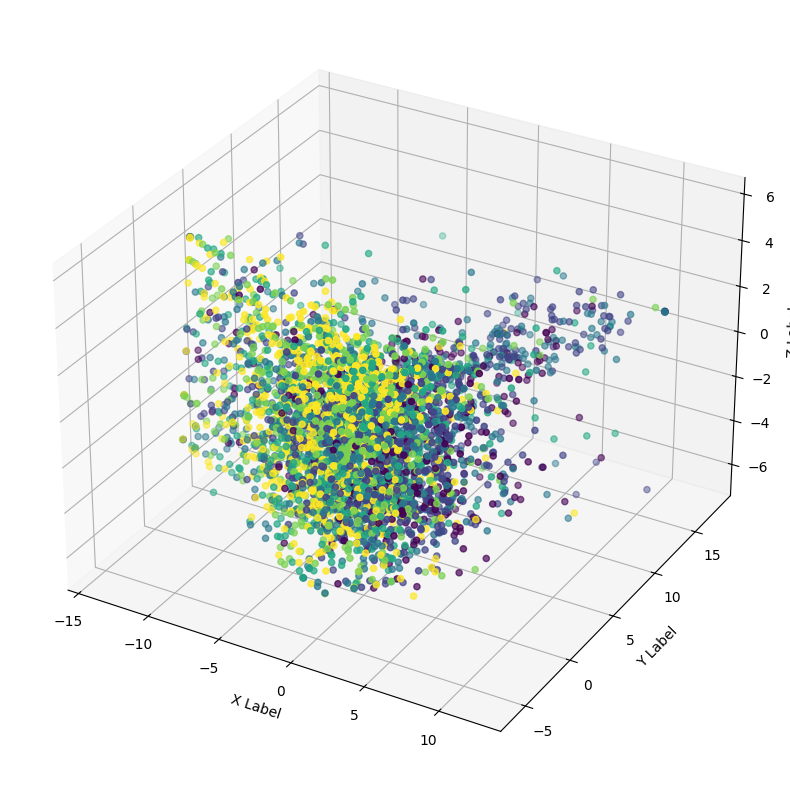

In [8]:
from sklearn.decomposition import PCA
import scipy
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

fig1 = plt.figure(figsize=(10, 10))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(X_pca[:,0], X_pca[:,1], X_pca[:,2], c = Y, marker='o')

# Set labels
ax1.set_xlabel('X Label')
ax1.set_ylabel('Y Label')
ax1.set_zlabel('Z Label')
plt.show()

NameError: name 'label_colors' is not defined

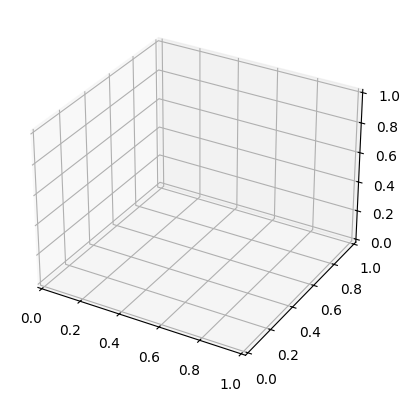

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)
xyz = X_pca[:, :3]
labels = Y

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)

# ---- Plot ----
fig = plt.figure()
ax = plt.subplot(projection='3d')

# Plot centers
#ax.scatter(centers[:, 1], centers[:, 2], centers[:, 3], s=120, marker='o')

# Annotate each center with its label
idz = centers[:,3].argmax()
label_with_max_z = int(centers[idz, 0])
max_z = centers[idz, 3]
for row in centers:
    #lab, cx, cy, cz = row
    #ax.text(cx, cy, cz, str(int(lab)))
    lab, cx, cy, cz = row
    color = label_colors[int(lab) - 1]
    print(color,lab)
    ax.scatter(cx, cy, cz**50, s=10, color=color)
    ax.text(cx, cy, cz, str(int(lab)))

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Cluster Centers by PCA")

plt.show()

In [17]:
cor0 = np.corrcoef(Y,X_pca[:,0])
cor1 = np.corrcoef(Y,X_pca[:,1])
cor2 = np.corrcoef(Y,X_pca[:,2])
cor3 = np.corrcoef(Y,X_pca[:,3])
cor4 = np.corrcoef(Y,X_pca[:,4])

print(cor0[0,1])
print(cor1[0,1])
print(cor2[0,1])
print(cor3[0,1])
print(cor4[0,1])
scipy.stats.spearmanr(Y, X_pca[:,0])

-0.20630811302663982
-0.2509180233269272
0.16021444180437447
0.09957525885289904
0.07567316724102625


SignificanceResult(statistic=-0.23015702707188815, pvalue=1.8723439858666124e-49)

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


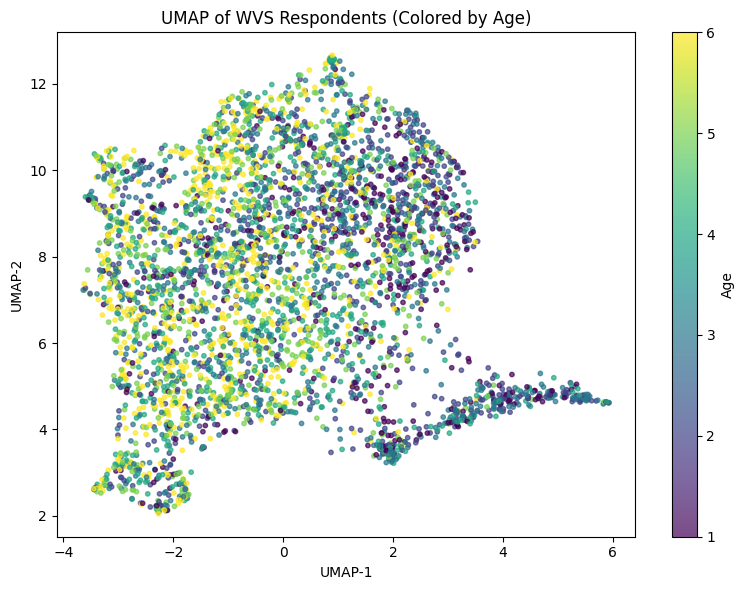

In [14]:
import umap
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.2,
    n_components=2,
    metric='euclidean',
    random_state=42
)

embedding = umap_model.fit_transform(X)

plt.figure(figsize=(8, 6))

sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=Y,
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.colorbar(sc, label='Age')
plt.title('UMAP of WVS Respondents (Colored by Age)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

plt.tight_layout()
plt.show()


In [21]:
"""
This function takes in the centroids of a 3d graph and outputs an adjacency matrix of trajectories
	centres = (np array) this is an array of shape num_classes x 3 where each row is the coordinates of the centroid of a class
	classes_lb = (np array) 1d array of classes in the associated encoded location. e.g. [cats, dogs, humans] where cats are class 0
	TOL = (float) tolerance for difference in activation energy (z) for ranking hierarchy
	FRWRD = (bool) if true, check trajectories by starting with highest z value and going down
	BACK = (bool) if true, check trajectories by starting with lowest z and seeing what points to it.
"""
def traj_adj_matrix(centres, classes_lb, DIM, TOL=0.01, FRWRD=True, BACK=True):
    done_lines = np.zeros((len(classes_lb), len(classes_lb)))


    if BACK:
    #Backward Lines
	    for m, pointa in enumerate(centres):
	        min_dist = 99999999
	        u = -1
	        
	        
	        for n, pointb in enumerate(centres):
	            if (pointb == pointa).all():
	                continue
	            a = np.copy(pointa)
	            b = np.copy(pointb)
	            a[2] = pointa[2]*DIM
	            b[2] = pointb[2]*DIM
	            dist_tmp = np.linalg.norm(a-b)
	            if min_dist > dist_tmp and (pointb[2] > pointa[2] or abs(pointa[2] - pointb[2]) <= TOL):
	                u = n
	                min_dist = dist_tmp
	        if u != -1:
	            done_lines[u][m] = 1

    #Forward Lines
    if FRWRD:
	    for m, pointa in enumerate(centres):
	        min_dist = 999999999
	        u = -1
	        if np.sum(done_lines[:][m]) or np.sum(done_lines[m]):
	            continue

	        for n, pointb in enumerate(centres):
	            if (pointb == pointa).all():
	                continue

	            a = np.copy(pointa)
	            b = np.copy(pointb)
	            a[2] = pointa[2]*DIM
	            b[2] = pointb[2]*DIM
	            dist_tmp = np.linalg.norm(a-b)
	            if min_dist >= dist_tmp and not done_lines[m][n] and (pointa[2] > pointb[2] or abs(pointa[2] - pointb[2]) <= TOL):

	                u = n
	                min_dist = dist_tmp
	        if u != -1:
	            done_lines[m][u] = 1
		           


    #handle conflicts of bidirectional trajectories by z
    for i in range(len(classes_lb)):
        for j in range(len(classes_lb)):
            if done_lines[i][j] and done_lines[j][i]:
                if centres[i][2] > centres[j][2]:
                    done_lines[j][i] = 0
                    done_lines[i][j] = 1
                else:
                    done_lines[i][j] = 0
                    done_lines[j][i] = 1

    return done_lines

In [32]:
cent_xyz = centers[:5,1:4]
labs = centers[:5,0]
liners = traj_adj_matrix(cent_xyz, labs, SOM_DIM, TOL=0, BACK=0, FRWRD=1)

In [33]:
liners

array([[0., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [39]:
# run centers for UMAP
# compare "traj" of UMAP to us
# run deeper PCAs 
# run spearman and pearson for each som without
# look at other questions (M/F) 

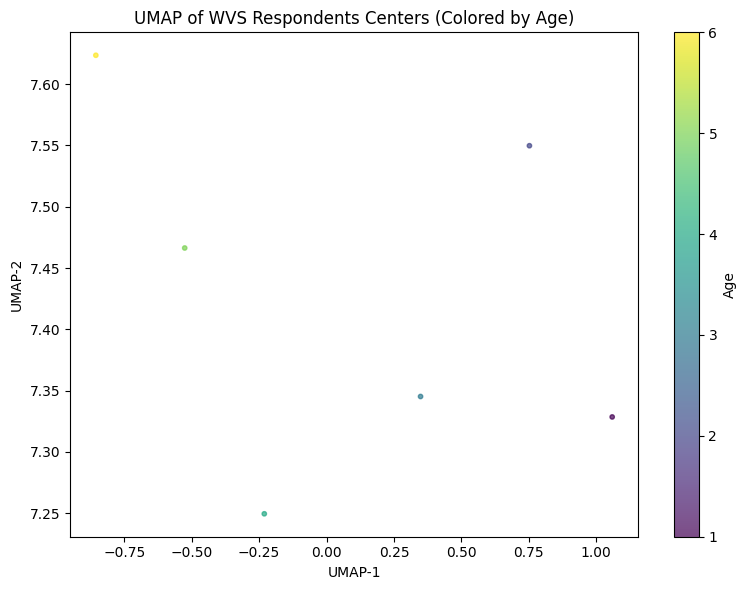

In [40]:
xyz = embedding
labels = Y

unique_labels = np.unique(labels)

centers = []

# ---- Compute center (mean x,y,z) for each label ----
for lab in unique_labels:
    points = xyz[labels == lab]
    center = points.mean(axis=0)
    centers.append((lab, center))

centers = np.array([(lab, *center) for lab, center in centers])
# centers shape: (num_labels, 4) → (label, cx, cy, cz)
plt.figure(figsize=(8, 6))

sc = plt.scatter(
    centers[:, 1],
    centers[:, 2],
    c=centers[:,0],
    cmap='viridis',
    s=10,
    alpha=0.7
)

plt.colorbar(sc, label='Age')
plt.title('UMAP of WVS Respondents Centers (Colored by Age)')
plt.xlabel('UMAP-1')
plt.ylabel('UMAP-2')

plt.tight_layout()
plt.show()

In [18]:
umap_cor0 = np.corrcoef(Y,embedding[:,0])
umap_cor1 = np.corrcoef(Y,embedding[:,1])
print(umap_cor0[0,1],umap_cor1[0,1])
scipy.stats.spearmanr(Y, embedding[:,1])

-0.3149743908308311 0.021078047567213393


SignificanceResult(statistic=0.016681122650802297, pvalue=0.2904556929833229)

In [ ]:
# can we create linear regression model to predict
# 

In [9]:
from sklearn.manifold import TSNE

In [11]:
tsne = TSNE(n_components=3, random_state=2, perplexity=30)
emb = tsne.fit_transform(X)

In [12]:
emb

array([[-20.674149  ,   7.7768393 ,   2.261572  ],
       [  9.452532  , -13.155104  , -11.988373  ],
       [ 22.200039  ,   1.7674406 ,   2.906487  ],
       ...,
       [ -5.481067  ,   9.683989  ,   8.908355  ],
       [  0.15882485, -18.248095  ,  -0.20795426],
       [ -0.47098884, -12.762786  ,  -1.7325288 ]], dtype=float32)

In [16]:
cor0 = np.corrcoef(Y,emb[:,0])
cor1 = np.corrcoef(Y,emb[:,1])
cor2 = np.corrcoef(Y,emb[:,2])

print(cor0[0,1])
print(cor1[0,1])
print(cor2[0,1])
scipy.stats.spearmanr(Y, emb[:,1])

-0.1909217343490113
-0.22735948021907454
-0.06933120134846282


SignificanceResult(statistic=-0.21197589972431438, pvalue=4.771964467859188e-42)

In [18]:
import scipy
import umap

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
umaper = umap.UMAP(
    n_components=5,       # Target 5D
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=2)
um_emb = umaper.fit_transform(X)

/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:
print(np.corrcoef(Y,um_emb[:,0])[0,1])
print(np.corrcoef(Y,um_emb[:,1])[0,1])
print(np.corrcoef(Y,um_emb[:,2])[0,1])
print(np.corrcoef(Y,um_emb[:,3])[0,1])
print(np.corrcoef(Y,um_emb[:,4])[0,1])
scipy.stats.spearmanr(Y, um_emb[:,0])

0.34170743215441984
0.10237016300264605
0.08623616888911118
0.14570773444069587
-0.040559758791575064


SignificanceResult(statistic=0.3408902752412356, pvalue=6.907359960857449e-110)

In [58]:
import scipy
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import PCA
def compare(X,Y):
    comps = 22
    all_cors = []
    pca = PCA(n_components=comps)
    X_pca = pca.fit_transform(X)
    print("PCA's calc'ed")
    p_max_cor = 0
    p_max_cor_ind = 0
    for i in range(comps):
        cor = np.corrcoef(Y,X_pca[:,i])[0,1]
        if abs(p_max_cor) < abs(cor):
            p_max_cor = cor
            p_max_cor_ind = i
    p_sp = scipy.stats.spearmanr(Y, X_pca[:,p_max_cor_ind])
    all_cors.append((p_max_cor, p_sp.statistic, p_sp.pvalue))
    print("PCA stats calc'ed")
    del pca, X_pca
    global umap
    umap_model = umap.UMAP(n_components=comps, n_neighbors=comps,min_dist=0.2,metric='euclidean',random_state=2)
    X_umap = umap_model.fit_transform(X)
    #print(X_umap.shape)
    print("UMAP calc'ed")
    u_max_cor = 0
    u_max_cor_ind = 0
    for i in range(comps):
        cor = np.corrcoef(Y,X_umap[:,i])[0,1]
        if abs(u_max_cor) < abs(cor):
            u_max_cor = cor
            u_max_cor_ind = i
    u_sp = scipy.stats.spearmanr(Y, X_umap[:,u_max_cor_ind])
    all_cors.append((u_max_cor, u_sp.statistic, u_sp.pvalue))
    print("UMAP stats calc'ed")
    del umap, X_umap
    tsne = TSNE(n_components=3, random_state=2, perplexity=30)
    X_tsne = tsne.fit_transform(X)
    print("TSNE calc'ed")
    t_max_cor = 0
    t_max_cor_ind = 0
    for i in range(3):
        cor = np.corrcoef(Y,X_tsne[:,i])[0,1]
        if abs(t_max_cor) < abs(cor):
            t_max_cor = cor
            t_max_cor_ind = i
    t_sp = scipy.stats.spearmanr(Y, X_tsne[:,t_max_cor_ind])
    all_cors.append((t_max_cor, t_sp.statistic, t_sp.pvalue))
    print(all_cors)
    return all_cors

In [59]:
l = compare(X,Y)

PCA's calc'ed
PCA stats calc'ed


/opt/homebrew/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP calc'ed
UMAP stats calc'ed
TSNE calc'ed
[(-0.2509180233269272, -0.22775559180584543, 1.944971105046204e-48), (-0.3504716101270577, -0.35290389296964975, 3.638783250431369e-118), (-0.22735948021907454, -0.21197589972431438, 4.771964467859188e-42)]
